10_final_model_selection: 最终模型选择

1. 加载所有候选模型...
✓ 所有模型加载成功

2. 准备验证数据...

准备05模型的数据（无特征工程）...
05模型特征数: 42

准备07/08模型的数据（有特征工程）...
07/08模型特征数: 45
验证集大小: (140000, 45)

3. 获取所有模型预测...

预测05_xgboost...
05_xgboost: AUC = 0.7264

预测07_xgboost...
07_xgboost: AUC = 0.7251

预测08_lightgbm...
08_lightgbm: AUC = 0.7248
09_ensemble: AUC = 0.7256

4. 最终模型对比
模型                   AUC        相比最佳        
05_xgboost           0.7264     +0.0000
07_xgboost           0.7251     -0.0013
08_lightgbm          0.7248     -0.0015
09_ensemble          0.7256     -0.0008
🏆 最佳模型: 05_xgboost (AUC=0.7264)


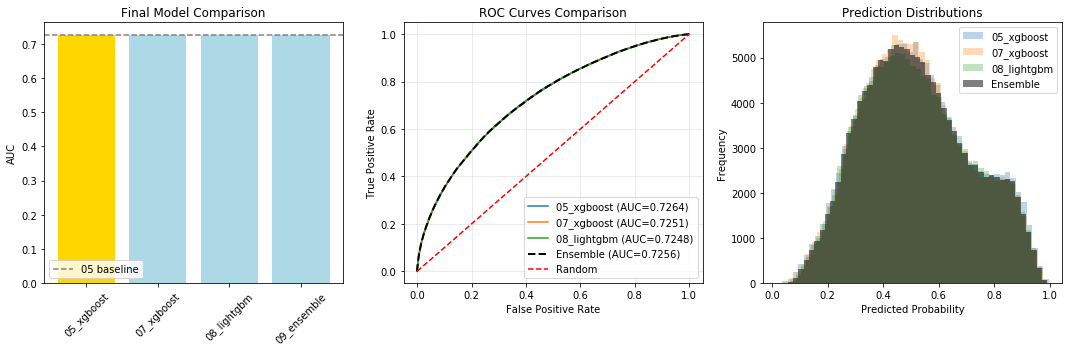


5. 生成最终Kaggle提交文件...

使用05_xgboost模型预测...
✅ 最终提交文件已保存: ../submissions/10_final_submission.csv

提交文件预览:
       id  diagnosed_diabetes
0  700000            0.366514
1  700001            0.551686
2  700002            0.684530
3  700003            0.299144
4  700004            0.908494

预测值统计:
最小值: 0.0197
最大值: 0.9961
平均值: 0.5013

🎯 项目完成！


In [5]:
# 10_final_model_selection.ipynb (最终修复版)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import joblib
import lightgbm as lgb

print("="*60)
print("10_final_model_selection: 最终模型选择")
print("="*60)

# 1. 加载所有最佳模型
print("\n1. 加载所有候选模型...")

models = {
    '05_xgboost': joblib.load('../models/05_xgboost_test_2_depth6.pkl'),
    '07_xgboost': joblib.load('../models/07_xgboost_test_4_lr0.1.pkl'),
    '08_lightgbm': lgb.Booster(model_file='../models/08_lightgbm_test_1.txt')
}
print("✓ 所有模型加载成功")

# 2. 加载验证集
print("\n2. 准备验证数据...")
train = pd.read_csv('../data/train.csv')

# 特征工程函数（用于07、08模型）
def create_selected_features(df):
    df_new = df.copy()
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    df_new['age_bmi'] = df['age'] * df['bmi']
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    return df_new

# 05模型使用的特征（没有特征工程）
print("\n准备05模型的数据（无特征工程）...")
X_05 = train.drop(['id', 'diagnosed_diabetes'], axis=1)
categorical_cols = ['gender', 'ethnicity', 'education_level',
                   'income_level', 'smoking_status', 'employment_status']
X_05_encoded = pd.get_dummies(X_05, columns=categorical_cols)
print(f"05模型特征数: {X_05_encoded.shape[1]}")  # 应该是42

# 07/08模型使用的特征（有特征工程）
print("\n准备07/08模型的数据（有特征工程）...")
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']
X_fe = create_selected_features(X)

features_to_keep = [
    'age_family_history', 'age_bmi', 'cardio_risk_score',
    'cholesterol_ratio', 'non_hdl_cholesterol',
    'physical_activity_minutes_per_week', 'triglycerides', 'bmi',
    'ldl_cholesterol', 'cardiovascular_history', 'diet_score',
    'heart_rate', 'systolic_bp', 'diastolic_bp', 'hdl_cholesterol',
    'cholesterol_total', 'waist_to_hip_ratio', 'sleep_hours_per_day',
    'screen_time_hours_per_day', 'alcohol_consumption_per_week',
    'hypertension_history', 'gender', 'ethnicity', 'education_level',
    'income_level', 'smoking_status', 'employment_status'
]

X_selected = X_fe[features_to_keep]
X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"07/08模型特征数: {X_encoded.shape[1]}")  # 应该是45

# 分割数据
from sklearn.model_selection import train_test_split
# 为05模型准备数据
X_train_05, X_val_05, y_train_05, y_val_05 = train_test_split(
    X_05_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 为07/08模型准备数据
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

X_val_np = X_val.values.astype('float32')
print(f"验证集大小: {X_val.shape}")

# 3. 获取所有模型的预测
print("\n3. 获取所有模型预测...")

predictions = {}

# 05模型预测（用无特征工程的数据）
print("\n预测05_xgboost...")
pred_05 = models['05_xgboost'].predict_proba(X_val_05)[:, 1]
auc_05 = roc_auc_score(y_val_05, pred_05)
predictions['05_xgboost'] = pred_05
print(f"05_xgboost: AUC = {auc_05:.4f}")

# 07模型预测（用有特征工程的数据）
print("\n预测07_xgboost...")
pred_07 = models['07_xgboost'].predict_proba(X_val)[:, 1]
auc_07 = roc_auc_score(y_val, pred_07)
predictions['07_xgboost'] = pred_07
print(f"07_xgboost: AUC = {auc_07:.4f}")

# 08模型预测
print("\n预测08_lightgbm...")
pred_08 = models['08_lightgbm'].predict(X_val_np)
auc_08 = roc_auc_score(y_val, pred_08)
predictions['08_lightgbm'] = pred_08
print(f"08_lightgbm: AUC = {auc_08:.4f}")

# 融合模型预测（用07和08的预测）
ensemble_pred = (pred_07 + pred_08) / 2
ensemble_auc = roc_auc_score(y_val, ensemble_pred)
print(f"09_ensemble: AUC = {ensemble_auc:.4f}")

# 4. 模型对比表格
print("\n4. 最终模型对比")
print("="*70)
print(f"{'模型':<20} {'AUC':<10} {'相比最佳':<12}")
print("="*70)

all_results = {
    '05_xgboost': auc_05,
    '07_xgboost': auc_07,
    '08_lightgbm': auc_08,
    '09_ensemble': ensemble_auc
}

best_auc = max(all_results.values())
best_model_name = max(all_results, key=all_results.get)

for name, auc in all_results.items():
    diff = auc - best_auc
    print(f"{name:<20} {auc:<10.4f} {diff:+.4f}")

print("="*70)
print(f"🏆 最佳模型: {best_model_name} (AUC={best_auc:.4f})")

# 5. 可视化对比
plt.figure(figsize=(15, 5))

# AUC对比
plt.subplot(1, 3, 1)
models_list = list(all_results.keys())
aucs_list = list(all_results.values())
colors = ['gold' if m == best_model_name else 'lightblue' for m in models_list]
plt.bar(models_list, aucs_list, color=colors)
plt.axhline(y=0.7264, color='gray', linestyle='--', label='05 baseline')
plt.ylabel('AUC')
plt.title('Final Model Comparison')
plt.xticks(rotation=45)
plt.legend()

# ROC曲线对比
plt.subplot(1, 3, 2)
for name, pred in predictions.items():
    fpr, tpr, _ = roc_curve(y_val if name != '05_xgboost' else y_val_05, 
                            pred)
    plt.plot(fpr, tpr, label=f'{name} (AUC={all_results[name]:.4f})')

# 融合模型的ROC
fpr_ens, tpr_ens, _ = roc_curve(y_val, ensemble_pred)
plt.plot(fpr_ens, tpr_ens, 'k--', linewidth=2, 
         label=f'Ensemble (AUC={ensemble_auc:.4f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 预测分布
plt.subplot(1, 3, 3)
for name, pred in predictions.items():
    plt.hist(pred, bins=50, alpha=0.3, label=name)
plt.hist(ensemble_pred, bins=50, alpha=0.5, color='black', label='Ensemble')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Distributions')
plt.legend()

plt.tight_layout()
plt.savefig('../logs/10_final_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# 6. 生成最终提交文件
print("\n5. 生成最终Kaggle提交文件...")

test = pd.read_csv('../data/test.csv')

# 根据最佳模型选择相应的数据准备方式
if best_model_name == '05_xgboost':
    print("\n使用05_xgboost模型预测...")
    # 无特征工程的数据
    X_test = test.drop(['id'], axis=1)
    X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)
    
    # 特征对齐
    missing_cols = set(X_05_encoded.columns) - set(X_test_encoded.columns)
    for col in missing_cols:
        X_test_encoded[col] = 0
    X_test_encoded = X_test_encoded[X_05_encoded.columns]
    
    final_pred = models['05_xgboost'].predict_proba(X_test_encoded)[:, 1]
    
elif best_model_name == '08_lightgbm':
    print("\n使用08_lightgbm模型预测...")
    # 有特征工程的数据
    X_test = test.drop(['id'], axis=1)
    X_test_fe = create_selected_features(X_test)
    X_test_selected = X_test_fe[features_to_keep]
    X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)
    
    # 特征对齐
    missing_cols = set(X_encoded.columns) - set(X_test_encoded.columns)
    for col in missing_cols:
        X_test_encoded[col] = 0
    X_test_encoded = X_test_encoded[X_encoded.columns]
    X_test_np = X_test_encoded.values.astype('float32')
    
    final_pred = models['08_lightgbm'].predict(X_test_np)
    
elif best_model_name == '09_ensemble':
    print("\n使用融合模型预测...")
    # 需要两个模型的预测
    # 07模型的数据
    X_test = test.drop(['id'], axis=1)
    X_test_fe = create_selected_features(X_test)
    X_test_selected = X_test_fe[features_to_keep]
    X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)
    
    missing_cols = set(X_encoded.columns) - set(X_test_encoded.columns)
    for col in missing_cols:
        X_test_encoded[col] = 0
    X_test_encoded = X_test_encoded[X_encoded.columns]
    X_test_np = X_test_encoded.values.astype('float32')
    
    xgb_pred = models['07_xgboost'].predict_proba(X_test_encoded)[:, 1]
    lgb_pred = models['08_lightgbm'].predict(X_test_np)
    final_pred = (xgb_pred + lgb_pred) / 2
    
else:  # 07_xgboost
    print("\n使用07_xgboost模型预测...")
    # 有特征工程的数据
    X_test = test.drop(['id'], axis=1)
    X_test_fe = create_selected_features(X_test)
    X_test_selected = X_test_fe[features_to_keep]
    X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)
    
    missing_cols = set(X_encoded.columns) - set(X_test_encoded.columns)
    for col in missing_cols:
        X_test_encoded[col] = 0
    X_test_encoded = X_test_encoded[X_encoded.columns]
    
    final_pred = models['07_xgboost'].predict_proba(X_test_encoded)[:, 1]

# 保存提交文件
submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': final_pred
})
submission_path = '../submissions/10_final_submission.csv'
submission.to_csv(submission_path, index=False)
print(f"✅ 最终提交文件已保存: {submission_path}")

# 预览
print("\n提交文件预览:")
print(submission.head())
print(f"\n预测值统计:")
print(f"最小值: {final_pred.min():.4f}")
print(f"最大值: {final_pred.max():.4f}")
print(f"平均值: {final_pred.mean():.4f}")

print("\n" + "="*60)
print("🎯 项目完成！")
print("="*60)